In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, precision_recall_curve, confusion_matrix
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from xgboost import XGBClassifier
import joblib
import warnings
warnings.filterwarnings('ignore')

# =========================
# 1. LOAD DATA
# =========================
file_path = r"D:\B\prediction_data.xlsx"
data = pd.read_excel(file_path, sheet_name="vw_Churn")

# Store CustomerID before dropping
customer_ids = None
if 'CustomerID' in data.columns:
    customer_ids = data['CustomerID'].copy()
elif 'customerID' in data.columns:
    customer_ids = data['customerID'].copy()

print(f"Original dataset shape: {data.shape}")
print(f"Columns: {data.columns.tolist()[:10]}...")

# =========================
# 2. DATA CLEANING
# =========================
# Fix TotalCharges
if 'TotalCharges' in data.columns:
    data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')
    data['TotalCharges'] = data['TotalCharges'].fillna(0)

# Drop ID columns
if 'customerID' in data.columns:
    data.drop('customerID', axis=1, inplace=True)
if 'CustomerID' in data.columns:
    data.drop('CustomerID', axis=1, inplace=True)

# Fix Churn safely
if 'Churn' in data.columns:
    data['Churn'] = data['Churn'].astype(str).str.strip()
    data['Churn'] = data['Churn'].replace({'Yes': 1, 'No': 0})
    data['Churn'] = pd.to_numeric(data['Churn'], errors='coerce')
    data = data.dropna(subset=['Churn'])
    data['Churn'] = data['Churn'].astype(int)

print(f"After cleaning shape: {data.shape}")
print(f"Churn distribution:\n{data['Churn'].value_counts()}")

# =========================
# 3. FEATURE ENGINEERING
# =========================
if 'TotalCharges' in data.columns and 'tenure' in data.columns:
    data['AvgMonthlySpend'] = data['TotalCharges'] / (data['tenure'] + 1)

if 'tenure' in data.columns:
    data['IsNewCustomer'] = (data['tenure'] <= 12).astype(int)

if 'MonthlyCharges' in data.columns:
    data['HighValueCustomer'] = (data['MonthlyCharges'] > 80).astype(int)

if 'tenure' in data.columns and 'MonthlyCharges' in data.columns:
    data['Tenure_to_Charge'] = data['tenure'] / (data['MonthlyCharges'] + 1)

print("✓ Feature engineering completed")

# =========================
# 4. SERVICE FEATURES 
# =========================
print("\n" + "="*50)
print("CREATING SERVICE FEATURES")
print("="*50)

# Check for service columns
service_columns = ['PhoneService', 'InternetService']
existing_service_cols = []

for col in service_columns:
    if col in data.columns:
        existing_service_cols.append(col)
        print(f"✓ Found service column: {col}")
        
        # Convert to binary if needed
        if data[col].dtype == 'object':
            data[col] = data[col].map({'Yes': 1, 'No': 0}).fillna(0)
            print(f"  Converted {col} to binary (Yes=1, No=0)")
    else:
        print(f"✗ Service column not found: {col}")

# Create service count and combinations
if len(existing_service_cols) >= 1:
    data['ServiceCount'] = data[existing_service_cols].sum(axis=1)
    print(f"\n✓ Created ServiceCount: {data['ServiceCount'].value_counts().to_dict()}")
    
    # Create combination features (more informative)
    if len(existing_service_cols) == 2:
        data['BothServices'] = ((data['PhoneService'] == 1) & (data['InternetService'] == 1)).astype(int)
        data['OnlyPhone'] = ((data['PhoneService'] == 1) & (data['InternetService'] == 0)).astype(int)
        data['OnlyInternet'] = ((data['PhoneService'] == 0) & (data['InternetService'] == 1)).astype(int)
        data['NoServices'] = ((data['PhoneService'] == 0) & (data['InternetService'] == 0)).astype(int)
        
        print(f"  BothServices: {data['BothServices'].sum()} customers")
        print(f"  OnlyPhone: {data['OnlyPhone'].sum()} customers")
        print(f"  OnlyInternet: {data['OnlyInternet'].sum()} customers")
        print(f"  NoServices: {data['NoServices'].sum()} customers")

# =========================
# 5. HANDLE INTERNET SERVICE TYPE
# =========================
if 'InternetService' in data.columns:
    print("\n" + "="*50)
    print("PROCESSING INTERNET SERVICE TYPE")
    print("="*50)
    
    # Show distribution
    print(f"InternetService distribution:\n{data['InternetService'].value_counts()}")
    
    # Create binary indicators for each internet type
    if data['InternetService'].dtype == 'object':
        internet_dummies = pd.get_dummies(data['InternetService'], prefix='InternetType')
        data = pd.concat([data, internet_dummies], axis=1)
        print(f"Created internet type dummies: {internet_dummies.columns.tolist()}")
        
        # Drop the original column
        data = data.drop(columns=['InternetService'])

# =========================
# 6. ENCODING CATEGORICALS (PRESERVE ALL CONTRACT TYPES)
# =========================
categorical_cols = data.select_dtypes(include=['object']).columns.tolist()
if 'Churn' in categorical_cols:
    categorical_cols.remove('Churn')

print(f"\n" + "="*50)
print("ENCODING CATEGORICAL VARIABLES")
print("="*50)
print(f"Categorical columns to encode: {categorical_cols}")

# Handle Contract column specially (if it exists)
if 'Contract' in categorical_cols:
    print("\nContract column values:", data['Contract'].value_counts().to_dict())
    
    # Create binary columns for EACH contract type
    contract_dummies = pd.get_dummies(data['Contract'], prefix='Contract')
    data = pd.concat([data, contract_dummies], axis=1)
    
    # Remove original Contract column
    data = data.drop(columns=['Contract'])
    categorical_cols.remove('Contract')
    
    print(f"Created contract dummy columns: {contract_dummies.columns.tolist()}")

# Handle other categorical columns
for col in categorical_cols:
    n_unique = data[col].nunique()
    print(f"  {col}: {n_unique} unique values")
    
    if n_unique <= 10:
        # Low cardinality: create dummies for ALL categories
        dummies = pd.get_dummies(data[col], prefix=col)
        data = pd.concat([data, dummies], axis=1)
        data = data.drop(columns=[col])
        print(f"    → One-hot encoded to {dummies.shape[1]} columns")
    else:
        # High cardinality: use frequency encoding
        freq_encoding = data[col].value_counts(normalize=True).to_dict()
        data[f'{col}_freq'] = data[col].map(freq_encoding)
        data = data.drop(columns=[col])
        print(f"    → Frequency encoded to {col}_freq")

print(f"\n✓ Encoding complete. Total features: {data.shape[1]}")

# =========================
# 7. VERIFY CONTRACT COLUMNS EXIST
# =========================
print("\n" + "="*50)
print("VERIFYING CONTRACT COLUMNS")
print("="*50)
contract_features = [col for col in data.columns if 'Contract' in col]
print(f"Contract-related features: {contract_features}")

# =========================
# 8. FEATURE SELECTION
# =========================
print("\n" + "="*50)
print("FEATURE SELECTION")
print("="*50)

X = data.drop('Churn', axis=1)
y = data['Churn']

print(f"Before selection: {X.shape[1]} features")

# Remove constant features
constant_cols = [col for col in X.columns if X[col].nunique() <= 1]
X = X.drop(columns=constant_cols)
print(f"Removed {len(constant_cols)} constant features")

# Remove highly correlated features
corr_matrix = X.corr().abs()
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_cols = [col for col in upper_triangle.columns if any(upper_triangle[col] > 0.95)]
X = X.drop(columns=high_corr_cols)
print(f"Removed {len(high_corr_cols)} highly correlated features")

# Select top features
k_features = min(100, X.shape[1])
selector = SelectKBest(score_func=mutual_info_classif, k=k_features)
X_selected = selector.fit_transform(X, y)
selected_mask = selector.get_support()
selected_features = X.columns[selected_mask].tolist()
X = pd.DataFrame(X_selected, columns=selected_features)

print(f"After selection: {len(selected_features)} features")
print(f"Contract features retained: {[f for f in selected_features if 'Contract' in f]}")

# =========================
# 9. TRAIN/TEST SPLIT
# =========================
print("\n" + "="*50)
print("TRAIN/TEST SPLIT")
print("="*50)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

# Align Customer IDs
if customer_ids is not None:
    data_with_ids = pd.DataFrame({'CustomerID': customer_ids, 'index': range(len(customer_ids))})
    data_with_ids = data_with_ids.iloc[X.index]
    customer_ids_aligned = data_with_ids['CustomerID']
    customer_ids_train = customer_ids_aligned.iloc[X_train.index]
    customer_ids_test = customer_ids_aligned.iloc[X_test.index]
else:
    customer_ids_test = None
    print("Warning: No CustomerID column found")

# =========================
# 10. MODEL TRAINING
# =========================
print("\n" + "="*50)
print("TRAINING XGBOOST MODEL")
print("="*50)

scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])
print(f"Scale pos weight: {scale_pos_weight:.2f}")

model = XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss',
    verbosity=0
)

model.fit(X_train, y_train)
print("✓ Model training complete")

# =========================
# 11. PREDICTIONS & THRESHOLD TUNING
# =========================
print("\n" + "="*50)
print("MAKING PREDICTIONS")
print("="*50)

y_probs = model.predict_proba(X_test)[:, 1]

# Find optimal threshold
precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx = np.argmax(f1_scores)
best_thresh = thresholds[best_idx]
final_thresh = max(best_thresh, 0.50)
y_pred = (y_probs > final_thresh).astype(int)

print(f"Best threshold (F1 optimized): {best_thresh:.3f}")
print(f"Final threshold used: {final_thresh:.3f}")

# =========================
# 12. EVALUATION
# =========================
print("\n" + "="*60)
print("MODEL PERFORMANCE")
print("="*60)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
print(f"\nConfusion Matrix:")
print(f"  True Negatives:  {tn:4d}  |  False Positives: {fp:4d}")
print(f"  False Negatives: {fn:4d}  |  True Positives:  {tp:4d}")

print(f"\nKey Metrics:")
print(f"  Accuracy:  {(tp+tn)/(tp+tn+fp+fn):.3f}")
print(f"  Recall:    {tp/(tp+fn):.3f} ({tp/(tp+fn)*100:.1f}%)")
print(f"  Precision: {tp/(tp+fp):.3f} ({tp/(tp+fp)*100:.1f}%)")
print(f"  F1-Score:  {2*tp/(2*tp+fp+fn):.3f}")

# =========================
# 13. CREATE RESULTS DATAFRAME WITH CUSTOMER IDs
# =========================
print("\n" + "="*50)
print("SAVING RESULTS")
print("="*50)

# Create results dataframe
results_df = pd.DataFrame()
results_df['CustomerID'] = customer_ids_test.values if customer_ids_test is not None else range(len(y_test))
results_df['Actual_Churn'] = y_test.values
results_df['Predicted_Churn'] = y_pred
results_df['Churn_Probability'] = y_probs

# Add risk tiers
results_df['Risk_Tier'] = pd.cut(y_probs, 
                                  bins=[0, 0.3, 0.5, 0.7, 1], 
                                  labels=['Low', 'Medium', 'High', 'Very High'])

# Add action recommendations
def get_action(prob):
    if prob >= 0.7:
        return "Immediate Retention Call"
    elif prob >= 0.5:
        return "Automated Discount Offer"
    elif prob >= 0.3:
        return "Monitor"
    else:
        return "No Action"

results_df['Recommended_Action'] = results_df['Churn_Probability'].apply(get_action)

# Add prediction correctness
results_df['Prediction_Correct'] = results_df['Actual_Churn'] == results_df['Predicted_Churn']

# Display sample
print("\nSample of predictions (first 10 rows):")
print(results_df.head(10).to_string(index=False))

# =========================
# 14. SAVE TO CSV AND EXCEL
# =========================

# Save as CSV (for Power BI)
csv_filename = "churn_predictions_final.csv"
results_df.to_csv(csv_filename, index=False)
print(f"\n✓ Predictions saved as '{csv_filename}'")

# Save as Excel (with formatting)
excel_filename = "churn_predictions_final.xlsx"
results_df.to_excel(excel_filename, index=False)
print(f"✓ Predictions saved as '{excel_filename}'")

# Save summary statistics
summary_df = pd.DataFrame({
    'Metric': ['Total Customers', 'Predicted Churn', 'Actual Churn', 
               'Correctly Predicted Churn', 'Missed Churn (False Negatives)', 
               'False Alarms (False Positives)', 'Accuracy', 'Recall', 
               'Precision', 'F1-Score', 'Threshold Used'],
    'Value': [
        len(results_df),
        results_df['Predicted_Churn'].sum(),
        results_df['Actual_Churn'].sum(),
        tp,
        fn,
        fp,
        f"{(tp+tn)/(tp+tn+fp+fn):.3f}",
        f"{tp/(tp+fn):.3f}",
        f"{tp/(tp+fp):.3f}",
        f"{2*tp/(2*tp+fp+fn):.3f}",
        f"{final_thresh:.3f}"
    ]
})

summary_df.to_excel("churn_model_summary.xlsx", index=False)
print("✓ Model summary saved as 'churn_model_summary.xlsx'")

# =========================
# 15. SAVE MODEL AND ARTIFACTS
# =========================
joblib.dump(model, "xgb_churn_model_final.pkl")
joblib.dump(selected_features, "selected_features.pkl")
joblib.dump(final_thresh, "threshold.pkl")

print("\n✓ Model saved as 'xgb_churn_model_final.pkl'")
print("✓ Selected features saved as 'selected_features.pkl'")
print("✓ Threshold saved as 'threshold.pkl'")

# =========================
# 16. FEATURE IMPORTANCE (TOP 15)
# =========================
print("\n" + "="*60)
print("TOP 15 FEATURE IMPORTANCES")
print("="*60)

importance_df = pd.DataFrame({
    'Feature': selected_features,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print(importance_df.head(15).to_string(index=False))

# Show contract feature importance specifically
contract_features_imp = importance_df[importance_df['Feature'].str.contains('Contract', case=False)]
if not contract_features_imp.empty:
    print("\n" + "="*60)
    print("CONTRACT FEATURE IMPORTANCE")
    print("="*60)
    print(contract_features_imp.to_string(index=False))

# =========================
# 17. HIGH RISK CUSTOMERS REPORT
# =========================
print("\n" + "="*60)
print("TOP 20 HIGHEST RISK CUSTOMERS")
print("="*60)

high_risk_customers = results_df.nlargest(20, 'Churn_Probability')[
    ['CustomerID', 'Churn_Probability', 'Risk_Tier', 'Recommended_Action']
]
print(high_risk_customers.to_string(index=False))

# Save high risk customers separately
high_risk_customers.to_csv("high_risk_customers.csv", index=False)
print("\n✓ High risk customers saved as 'high_risk_customers.csv'")

# =========================
# 18. FINAL SUMMARY
# =========================
print("\n" + "="*60)
print("PRODUCTION READY SUMMARY")
print("="*60)
print(f"""
Files created:
1. {csv_filename} - Main predictions with Customer IDs
2. {excel_filename} - Excel version of predictions
3. churn_model_summary.xlsx - Performance metrics
4. high_risk_customers.csv - Top 20 highest risk customers
5. xgb_churn_model_final.pkl - Saved model for future use
6. selected_features.pkl - List of features used
7. threshold.pkl - Optimal threshold value

Model Performance:
- Catches {tp/(tp+fn)*100:.1f}% of actual churners
- {tp/(tp+fp)*100:.1f}% of predicted churners actually churn
- Overall accuracy: {(tp+tn)/(tp+tn+fp+fn)*100:.1f}%

Ready for deployment! 🚀
""")

Original dataset shape: (7043, 14)
Columns: ['CustomerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'TenureGroup', 'PhoneService', 'InternetService', 'Contract']...
After cleaning shape: (7043, 13)
Churn distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64
✓ Feature engineering completed

CREATING SERVICE FEATURES
✓ Found service column: PhoneService
  Converted PhoneService to binary (Yes=1, No=0)
✓ Found service column: InternetService
  Converted InternetService to binary (Yes=1, No=0)

✓ Created ServiceCount: {1.0: 6361, 0.0: 682}
  BothServices: 0 customers
  OnlyPhone: 6361 customers
  OnlyInternet: 0 customers
  NoServices: 682 customers

PROCESSING INTERNET SERVICE TYPE
InternetService distribution:
InternetService
0.0    7043
Name: count, dtype: int64

ENCODING CATEGORICAL VARIABLES
Categorical columns to encode: ['gender', 'TenureGroup', 'Contract', 'PaymentMethod']

Contract column values: {'Month-to-month': 3875, 'Two year': 1695, 'One year

In [5]:
print("Final shape:", data.shape)

Final shape: (7043, 29)


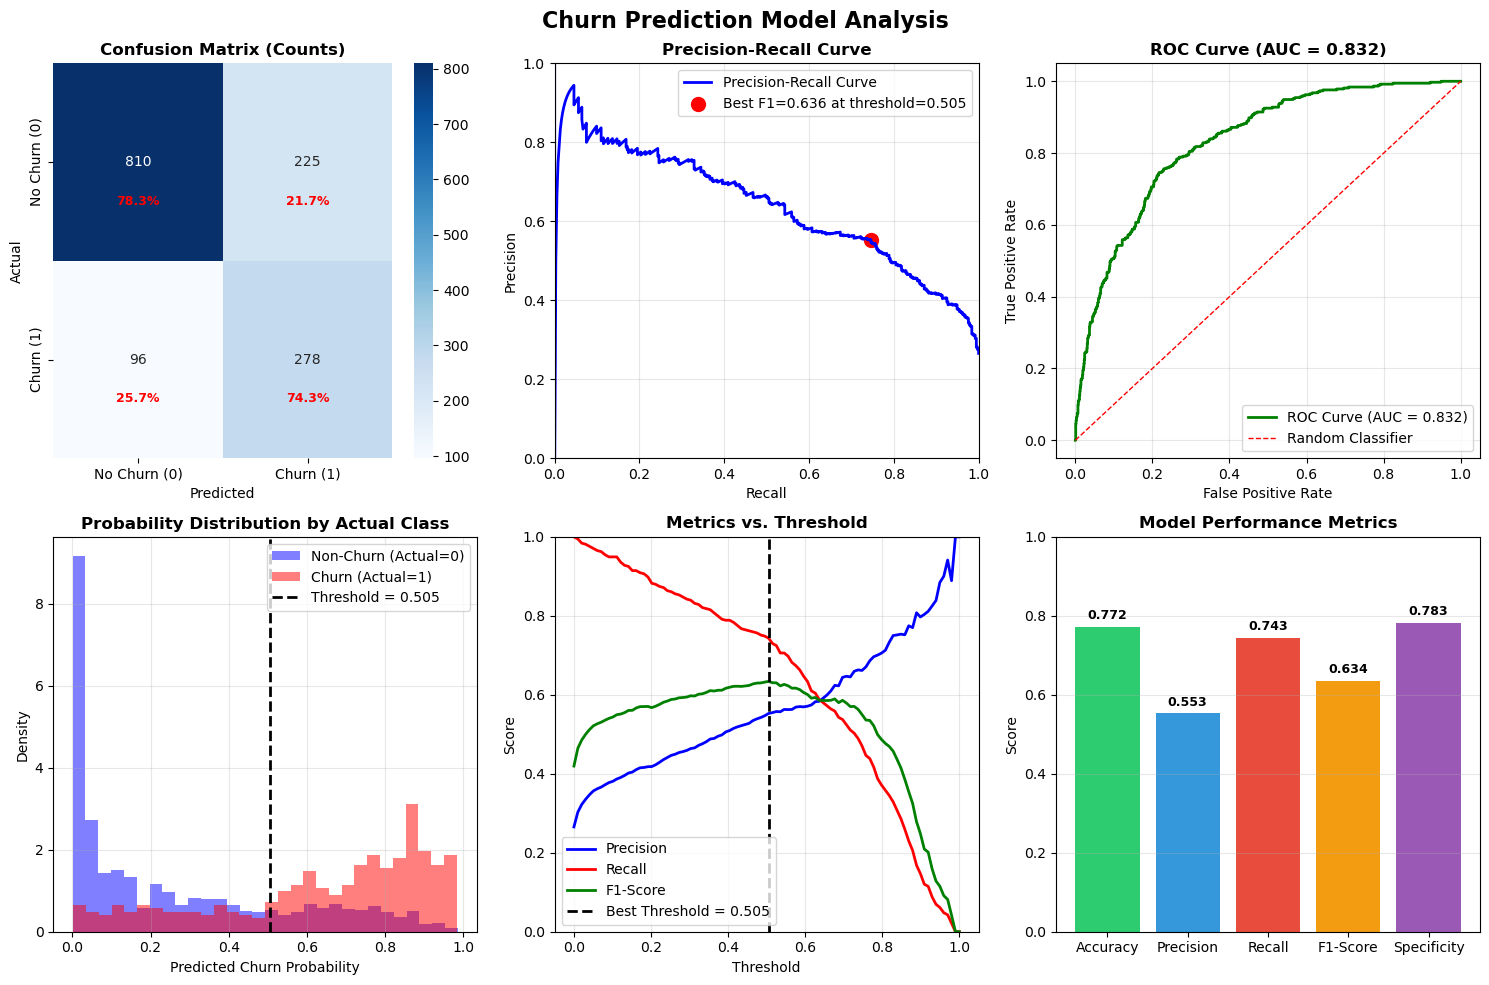

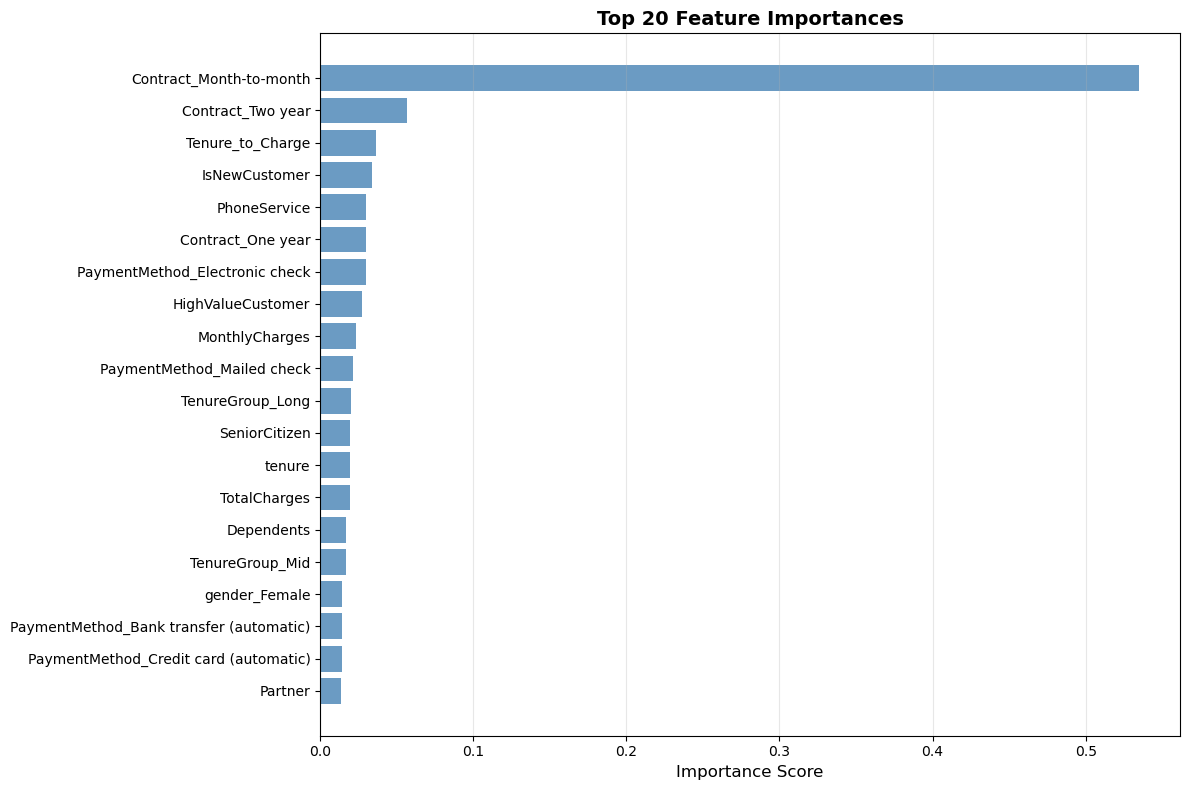

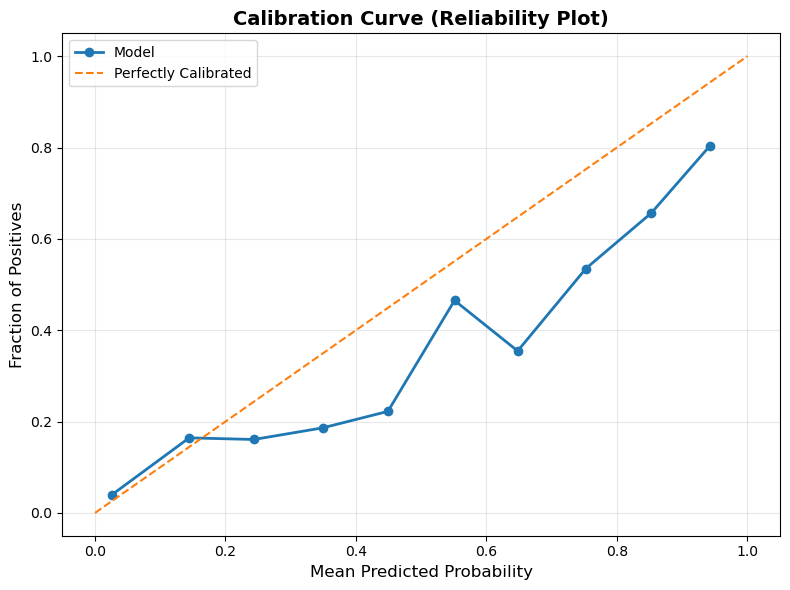

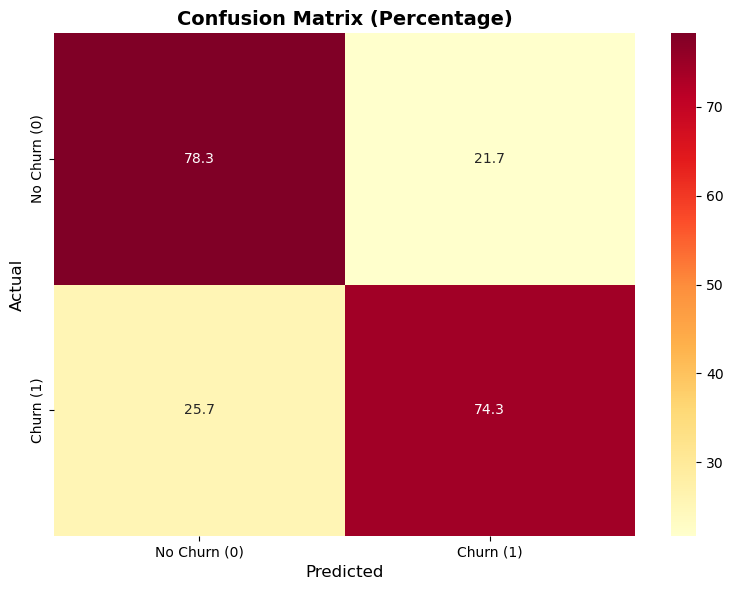

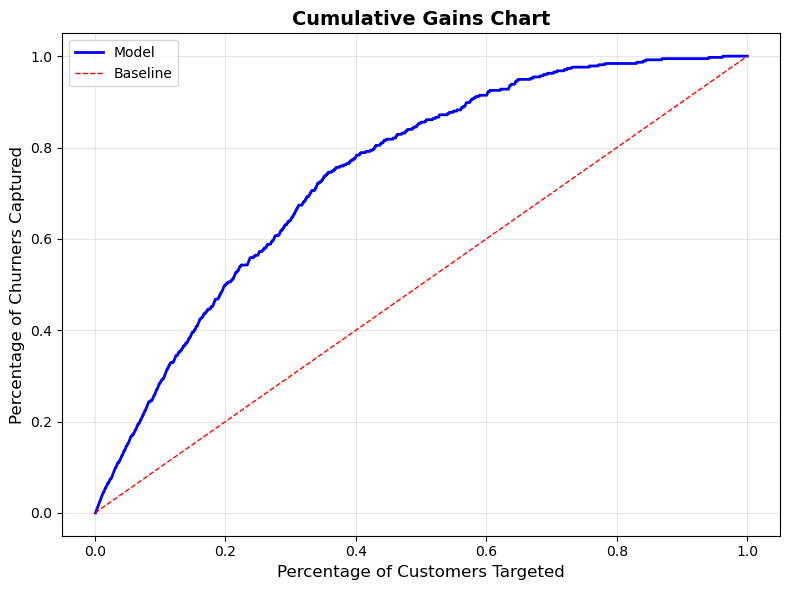


MODEL PERFORMANCE SUMMARY
Confusion Matrix:
  True Negatives:   810  |  False Positives:  225
  False Negatives:   96  |  True Positives:   278

Key Metrics:
  Accuracy:    0.772 (77.2%)
  Precision:   0.553 (55.3%)
  Recall:      0.743 (74.3%)
  F1-Score:    0.634
  Specificity: 0.783
  AUC-ROC:     0.832

Optimal Threshold: 0.505


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import roc_curve, auc, precision_recall_curve
import warnings
warnings.filterwarnings('ignore')

# =========================
# LOAD RESULTS

# =========================
# 1. CONFUSION MATRIX HEATMAP
# =========================
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Churn Prediction Model Analysis', fontsize=16, fontweight='bold')

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
cm_percentage = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0],
            xticklabels=['No Churn (0)', 'Churn (1)'],
            yticklabels=['No Churn (0)', 'Churn (1)'])
axes[0, 0].set_title('Confusion Matrix (Counts)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Predicted', fontsize=10)
axes[0, 0].set_ylabel('Actual', fontsize=10)

# Add percentages
for i in range(2):
    for j in range(2):
        axes[0, 0].text(j+0.5, i+0.7, f'{cm_percentage[i, j]:.1f}%', 
                       ha='center', va='center', color='red', fontsize=9, fontweight='bold')

# =========================
# 2. PRECISION-RECALL CURVE
# =========================
precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx = np.argmax(f1_scores)
best_thresh = thresholds[best_idx]

axes[0, 1].plot(recalls, precisions, 'b-', linewidth=2, label='Precision-Recall Curve')
axes[0, 1].scatter(recalls[best_idx], precisions[best_idx], color='red', s=100, 
                   label=f'Best F1={f1_scores[best_idx]:.3f} at threshold={best_thresh:.3f}')
axes[0, 1].set_xlabel('Recall', fontsize=10)
axes[0, 1].set_ylabel('Precision', fontsize=10)
axes[0, 1].set_title('Precision-Recall Curve', fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_xlim([0, 1])
axes[0, 1].set_ylim([0, 1])

# =========================
# 3. ROC CURVE
# =========================
fpr, tpr, roc_thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

axes[0, 2].plot(fpr, tpr, 'g-', linewidth=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
axes[0, 2].plot([0, 1], [0, 1], 'r--', linewidth=1, label='Random Classifier')
axes[0, 2].set_xlabel('False Positive Rate', fontsize=10)
axes[0, 2].set_ylabel('True Positive Rate', fontsize=10)
axes[0, 2].set_title(f'ROC Curve (AUC = {roc_auc:.3f})', fontsize=12, fontweight='bold')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# =========================
# 4. PROBABILITY DISTRIBUTION
# =========================
# Separate probabilities by actual class
churn_probs = y_probs[y_test == 1]
non_churn_probs = y_probs[y_test == 0]

axes[1, 0].hist(non_churn_probs, bins=30, alpha=0.5, color='blue', label='Non-Churn (Actual=0)', density=True)
axes[1, 0].hist(churn_probs, bins=30, alpha=0.5, color='red', label='Churn (Actual=1)', density=True)
axes[1, 0].axvline(x=best_thresh, color='black', linestyle='--', linewidth=2, 
                   label=f'Threshold = {best_thresh:.3f}')
axes[1, 0].set_xlabel('Predicted Churn Probability', fontsize=10)
axes[1, 0].set_ylabel('Density', fontsize=10)
axes[1, 0].set_title('Probability Distribution by Actual Class', fontsize=12, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# =========================
# 5. THRESHOLD ANALYSIS
# =========================
threshold_range = np.linspace(0, 1, 100)
metrics_df = pd.DataFrame({'threshold': threshold_range})

metrics_df['precision'] = [precisions[np.argmax(thresholds >= t)] if len(thresholds[thresholds >= t]) > 0 else precisions[-1] for t in threshold_range]
metrics_df['recall'] = [recalls[np.argmax(thresholds >= t)] if len(thresholds[thresholds >= t]) > 0 else recalls[-1] for t in threshold_range]
metrics_df['f1'] = 2 * (metrics_df['precision'] * metrics_df['recall']) / (metrics_df['precision'] + metrics_df['recall'] + 1e-10)

axes[1, 1].plot(threshold_range, metrics_df['precision'], 'b-', linewidth=2, label='Precision')
axes[1, 1].plot(threshold_range, metrics_df['recall'], 'r-', linewidth=2, label='Recall')
axes[1, 1].plot(threshold_range, metrics_df['f1'], 'g-', linewidth=2, label='F1-Score')
axes[1, 1].axvline(x=best_thresh, color='black', linestyle='--', linewidth=2, 
                   label=f'Best Threshold = {best_thresh:.3f}')
axes[1, 1].set_xlabel('Threshold', fontsize=10)
axes[1, 1].set_ylabel('Score', fontsize=10)
axes[1, 1].set_title('Metrics vs. Threshold', fontsize=12, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_ylim([0, 1])

# =========================
# 6. METRICS BAR CHART
# =========================
tn, fp, fn, tp = cm.ravel()
metrics = {
    'Accuracy': (tp+tn)/(tp+tn+fp+fn),
    'Precision': tp/(tp+fp),
    'Recall': tp/(tp+fn),
    'F1-Score': 2*tp/(2*tp+fp+fn),
    'Specificity': tn/(tn+fp)
}

bars = axes[1, 2].bar(metrics.keys(), metrics.values(), color=['#2ecc71', '#3498db', '#e74c3c', '#f39c12', '#9b59b6'])
axes[1, 2].set_ylim([0, 1])
axes[1, 2].set_ylabel('Score', fontsize=10)
axes[1, 2].set_title('Model Performance Metrics', fontsize=12, fontweight='bold')
axes[1, 2].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, value in zip(bars, metrics.values()):
    axes[1, 2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
                    f'{value:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# =========================
# 7. FEATURE IMPORTANCE PLOT 
# =========================
plt.figure(figsize=(12, 8))
importance = pd.Series(model.feature_importances_, index=selected_features)
importance = importance.sort_values(ascending=True).tail(20)  # Top 20

plt.barh(range(len(importance)), importance.values, color='steelblue', alpha=0.8)
plt.yticks(range(len(importance)), importance.index)
plt.xlabel('Importance Score', fontsize=12)
plt.title('Top 20 Feature Importances', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

# =========================
# 8. PREDICTION RELIABILITY PLOT (Calibration Curve)
# =========================
from sklearn.calibration import calibration_curve

plt.figure(figsize=(8, 6))
prob_true, prob_pred = calibration_curve(y_test, y_probs, n_bins=10)
plt.plot(prob_pred, prob_true, marker='o', linewidth=2, label='Model')
plt.plot([0, 1], [0, 1], linestyle='--', label='Perfectly Calibrated')
plt.xlabel('Mean Predicted Probability', fontsize=12)
plt.ylabel('Fraction of Positives', fontsize=12)
plt.title('Calibration Curve (Reliability Plot)', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# =========================
# 9. CONFUSION MATRIX - NORMALIZED VIEW
# =========================
plt.figure(figsize=(8, 6))
sns.heatmap(cm_percentage, annot=True, fmt='.1f', cmap='YlOrRd', 
            xticklabels=['No Churn (0)', 'Churn (1)'],
            yticklabels=['No Churn (0)', 'Churn (1)'])
plt.title('Confusion Matrix (Percentage)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.tight_layout()
plt.show()

# =========================
# 10. CUMULATIVE GAINS CHART
# =========================
plt.figure(figsize=(8, 6))
# Sort by probability
sorted_idx = np.argsort(y_probs)[::-1]
sorted_y = y_test.iloc[sorted_idx] if isinstance(y_test, pd.Series) else y_test[sorted_idx]
cumulative_churn = np.cumsum(sorted_y) / np.sum(sorted_y)
cumulative_population = np.arange(1, len(sorted_y) + 1) / len(sorted_y)

plt.plot(cumulative_population, cumulative_churn, 'b-', linewidth=2, label='Model')
plt.plot([0, 1], [0, 1], 'r--', linewidth=1, label='Baseline')
plt.xlabel('Percentage of Customers Targeted', fontsize=12)
plt.ylabel('Percentage of Churners Captured', fontsize=12)
plt.title('Cumulative Gains Chart', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# =========================
# PRINT SUMMARY STATISTICS
# =========================
print("\n" + "="*60)
print("MODEL PERFORMANCE SUMMARY")
print("="*60)
print(f"Confusion Matrix:")
print(f"  True Negatives:  {tn:4d}  |  False Positives: {fp:4d}")
print(f"  False Negatives: {fn:4d}  |  True Positives:  {tp:4d}")
print("\nKey Metrics:")
print(f"  Accuracy:    {metrics['Accuracy']:.3f} ({metrics['Accuracy']*100:.1f}%)")
print(f"  Precision:   {metrics['Precision']:.3f} ({metrics['Precision']*100:.1f}%)")
print(f"  Recall:      {metrics['Recall']:.3f} ({metrics['Recall']*100:.1f}%)")
print(f"  F1-Score:    {metrics['F1-Score']:.3f}")
print(f"  Specificity: {metrics['Specificity']:.3f}")
print(f"  AUC-ROC:     {roc_auc:.3f}")
print(f"\nOptimal Threshold: {best_thresh:.3f}")

In [ ]:
import pandas as pd
import numpy as np

# =========================
results_df = pd.read_csv("churn_predictions_final.csv")



# 1. Add segmentation columns
results_df['Churn_Risk_Score'] = (results_df['Churn_Probability'] * 100).round(2)

# 2. Risk categories (more detailed)
results_df['Risk_Category'] = pd.cut(
    results_df['Churn_Probability'],
    bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
    labels=['Very Low', 'Low', 'Medium', 'High', 'Very High']
)

# 3. Binary flags for filtering
results_df['Is_High_Risk'] = (results_df['Churn_Probability'] >= 0.5).astype(int)
results_df['Is_Very_High_Risk'] = (results_df['Churn_Probability'] >= 0.7).astype(int)
results_df['Is_Medium_Risk'] = ((results_df['Churn_Probability'] >= 0.3) & (results_df['Churn_Probability'] < 0.5)).astype(int)
results_df['Is_Low_Risk'] = (results_df['Churn_Probability'] < 0.3).astype(int)

# 4. Prediction confidence
results_df['Prediction_Confidence'] = np.where(
    results_df['Predicted_Churn'] == 1,
    results_df['Churn_Probability'],  # For churn predictions, confidence is the probability
    1 - results_df['Churn_Probability']  # For non-churn, confidence is 1-probability
)
results_df['Confidence_Level'] = pd.cut(
    results_df['Prediction_Confidence'],
    bins=[0, 0.5, 0.7, 0.9, 1.0],
    labels=['Low', 'Medium', 'High', 'Very High']
)

# 5. Business value columns
results_df['Retention_Cost_Estimate'] = np.where(
    results_df['Predicted_Churn'] == 1,
    np.where(results_df['Risk_Tier'] == 'Very High', 100,
             np.where(results_df['Risk_Tier'] == 'High', 50, 25)),
    0
)

results_df['Expected_Retention_Value'] = np.where(
    results_df['Predicted_Churn'] == 1,
    results_df['Churn_Probability'] * 500,  # Assume $500 customer lifetime value
    0
)

# 6. Error analysis columns
results_df['Prediction_Error'] = results_df['Actual_Churn'] - results_df['Predicted_Churn']
results_df['Error_Type'] = np.where(
    results_df['Prediction_Error'] == 0, 'Correct',
    np.where((results_df['Actual_Churn'] == 1) & (results_df['Predicted_Churn'] == 0), 'False Negative (Missed Churn)',
             'False Positive (Wrong Alert)')
)

# 7. Priority score for action
results_df['Priority_Score'] = (
    results_df['Churn_Probability'] * 100 +  # Risk score
    np.where(results_df['Predicted_Churn'] == 1, 20, 0) +  # Bonus for predicted churn
    np.where(results_df['Risk_Tier'] == 'Very High', 30, 0)  # Extra for very high risk
).round(2)

# 8. Action urgency
results_df['Action_Urgency'] = np.where(
    results_df['Priority_Score'] >= 80, 'Immediate (24 hours)',
    np.where(results_df['Priority_Score'] >= 60, 'High (3 days)',
             np.where(results_df['Priority_Score'] >= 40, 'Medium (1 week)',
                      'Low (2 weeks)'))
)

# 9. Week/ Month columns for time analysis
results_df['Prediction_Week'] = pd.Timestamp.now().strftime('%Y-W%W')
results_df['Prediction_Month'] = pd.Timestamp.now().strftime('%Y-%m')
results_df['Prediction_Date'] = pd.Timestamp.now().strftime('%Y-%m-%d')

# 10. Model version tracking
results_df['Model_Version'] = 'v2.0_XGBoost_Final'
results_df['Threshold_Used'] = 0.50  # Update with your actual threshold

# 11. Rolling ranks for prioritization
results_df['Risk_Rank'] = results_df['Churn_Probability'].rank(ascending=False, method='min').astype(int)
results_df['Priority_Rank'] = results_df['Priority_Score'].rank(ascending=False, method='min').astype(int)

# 12. Percentile groups
results_df['Risk_Percentile'] = pd.qcut(results_df['Churn_Probability'].rank(pct=True), 
                                         q=10, 
                                         labels=['0-10%', '10-20%', '20-30%', '30-40%', '40-50%', 
                                                 '50-60%', '60-70%', '70-80%', '80-90%', '90-100%'])

# 13. KPI flags for dashboard
results_df['Needs_Immediate_Action'] = (results_df['Priority_Score'] >= 70).astype(int)
results_df['Is_False_Positive'] = ((results_df['Actual_Churn'] == 0) & (results_df['Predicted_Churn'] == 1)).astype(int)
results_df['Is_False_Negative'] = ((results_df['Actual_Churn'] == 1) & (results_df['Predicted_Churn'] == 0)).astype(int)

# =========================
# REORDER COLUMNS FOR BETTER READABILITY
# =========================
column_order = [
    # Customer identification
    'CustomerID',
    
    # Predictions
    'Actual_Churn',
    'Predicted_Churn',
    'Churn_Probability',
    'Churn_Risk_Score',
    'Prediction_Confidence',
    'Confidence_Level',
    'Prediction_Correct',
    
    # Risk assessment
    'Risk_Tier',
    'Risk_Category',
    'Risk_Rank',
    'Risk_Percentile',
    'Is_High_Risk',
    'Is_Very_High_Risk',
    'Is_Medium_Risk',
    'Is_Low_Risk',
    
    # Action recommendations
    'Recommended_Action',
    'Action_Urgency',
    'Priority_Score',
    'Priority_Rank',
    'Needs_Immediate_Action',
    'Retention_Cost_Estimate',
    'Expected_Retention_Value',
    
    # Error analysis
    'Prediction_Error',
    'Error_Type',
    'Is_False_Positive',
    'Is_False_Negative',
    
    # Time tracking
    'Prediction_Date',
    'Prediction_Week',
    'Prediction_Month',
    'Model_Version',
    'Threshold_Used'
]

# Reorder columns (only include those that exist)
existing_columns = [col for col in column_order if col in results_df.columns]
missing_columns = [col for col in column_order if col not in results_df.columns]
if missing_columns:
    print(f"Warning: These columns not found and will be skipped: {missing_columns}")

results_df_enhanced = results_df[existing_columns]

# =========================
# SAVE ENHANCED CSV FOR POWER BI
# =========================
csv_filename = "churn_predictions_powerbi.csv"
results_df_enhanced.to_csv(csv_filename, index=False)
print(f"✓ Enhanced CSV saved as '{csv_filename}'")
print(f"✓ Total columns: {len(results_df_enhanced.columns)}")
print(f"✓ Total rows: {len(results_df_enhanced)}")

# =========================
# CREATE ADDITIONAL SUMMARY CSVs FOR POWER BI DASHBOARDS
# =========================

# 1. Summary by Risk Tier
risk_summary = results_df_enhanced.groupby('Risk_Tier').agg({
    'CustomerID': 'count',
    'Actual_Churn': 'sum',
    'Predicted_Churn': 'sum',
    'Churn_Probability': 'mean',
    'Expected_Retention_Value': 'sum'
}).rename(columns={
    'CustomerID': 'Customer_Count',
    'Actual_Churn': 'Actual_Churners',
    'Predicted_Churn': 'Predicted_Churners',
    'Churn_Probability': 'Avg_Churn_Probability',
    'Expected_Retention_Value': 'Total_Retention_Value'
}).reset_index()
risk_summary.to_csv("powerbi_risk_summary.csv", index=False)
print("✓ Risk summary saved as 'powerbi_risk_summary.csv'")

# 2. Daily prediction summary (if you run predictions regularly)
daily_summary = pd.DataFrame({
    'Date': [pd.Timestamp.now().strftime('%Y-%m-%d')],
    'Total_Customers': [len(results_df_enhanced)],
    'Predicted_Churners': [results_df_enhanced['Predicted_Churn'].sum()],
    'Actual_Churners': [results_df_enhanced['Actual_Churn'].sum()],
    'High_Risk_Customers': [results_df_enhanced['Is_High_Risk'].sum()],
    'Very_High_Risk': [results_df_enhanced['Is_Very_High_Risk'].sum()],
    'False_Positives': [results_df_enhanced['Is_False_Positive'].sum()],
    'False_Negatives': [results_df_enhanced['Is_False_Negative'].sum()],
    'Avg_Churn_Probability': [results_df_enhanced['Churn_Probability'].mean()],
    'Total_Retention_Budget': [results_df_enhanced['Retention_Cost_Estimate'].sum()],
    'Expected_CLV_Saved': [results_df_enhanced['Expected_Retention_Value'].sum()]
})
daily_summary.to_csv("powerbi_daily_summary.csv", index=False)
print("✓ Daily summary saved as 'powerbi_daily_summary.csv'")

# 3. Action priority list (for operations team)
action_list = results_df_enhanced[
    results_df_enhanced['Needs_Immediate_Action'] == 1
][['CustomerID', 'Priority_Score', 'Risk_Tier', 'Recommended_Action', 
   'Action_Urgency', 'Churn_Probability', 'Expected_Retention_Value']].sort_values('Priority_Score', ascending=False)
action_list.to_csv("powerbi_action_list.csv", index=False)
print("✓ Action list saved as 'powerbi_action_list.csv'")

# 4. Model performance metrics
# Calculate metrics safely
total_customers = len(results_df_enhanced)
correct_predictions = results_df_enhanced['Prediction_Correct'].sum()
predicted_churners = results_df_enhanced['Predicted_Churn'].sum()
actual_churners = results_df_enhanced['Actual_Churn'].sum()
true_positives = ((results_df_enhanced['Actual_Churn'] == 1) & (results_df_enhanced['Predicted_Churn'] == 1)).sum()
false_positives = results_df_enhanced['Is_False_Positive'].sum()
false_negatives = results_df_enhanced['Is_False_Negative'].sum()
true_negatives = total_customers - (true_positives + false_positives + false_negatives)

# Calculate metrics with safe division
accuracy = correct_predictions / total_customers if total_customers > 0 else 0
precision = true_positives / predicted_churners if predicted_churners > 0 else 0
recall = true_positives / actual_churners if actual_churners > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
false_positive_rate = false_positives / (false_positives + true_negatives) if (false_positives + true_negatives) > 0 else 0
false_negative_rate = false_negatives / (false_negatives + true_positives) if (false_negatives + true_positives) > 0 else 0

performance_metrics = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1_Score', 'False_Positive_Rate', 'False_Negative_Rate'],
    'Value': [
        round(accuracy, 3),
        round(precision, 3),
        round(recall, 3),
        round(f1_score, 3),
        round(false_positive_rate, 3),
        round(false_negative_rate, 3)
    ]
})
performance_metrics.to_csv("powerbi_performance_metrics.csv", index=False)
print("✓ Performance metrics saved as 'powerbi_performance_metrics.csv'")

# =========================
# DISPLAY SAMPLE OF ENHANCED DATA
# =========================
print("\n" + "="*60)
print("SAMPLE OF ENHANCED DATA (FIRST 5 ROWS)")
print("="*60)
print(results_df_enhanced.head().to_string())

print("\n" + "="*60)
print("COLUMNS AVAILABLE FOR POWER BI")
print("="*60)
for i, col in enumerate(results_df_enhanced.columns, 1):
    print(f"{i:2d}. {col}")

print(f"\n✅ Total {len(results_df_enhanced.columns)} columns exported")
print("\nFiles created for Power BI:")
print("  1. churn_predictions_powerbi.csv - Main data with all columns")
print("  2. powerbi_risk_summary.csv - Aggregated by risk tier")
print("  3. powerbi_daily_summary.csv - Daily KPIs")
print("  4. powerbi_action_list.csv - Priority action items")
print("  5. powerbi_performance_metrics.csv - Model performance")



✓ Enhanced CSV saved as 'churn_predictions_powerbi.csv'
✓ Total columns: 32
✓ Total rows: 1409
✓ Risk summary saved as 'powerbi_risk_summary.csv'
✓ Daily summary saved as 'powerbi_daily_summary.csv'
✓ Action list saved as 'powerbi_action_list.csv'
✓ Performance metrics saved as 'powerbi_performance_metrics.csv'

SAMPLE OF ENHANCED DATA (FIRST 5 ROWS)
   CustomerID  Actual_Churn  Predicted_Churn  Churn_Probability  Churn_Risk_Score  Prediction_Confidence Confidence_Level  Prediction_Correct  Risk_Tier Risk_Category  Risk_Rank Risk_Percentile  Is_High_Risk  Is_Very_High_Risk  Is_Medium_Risk  Is_Low_Risk        Recommended_Action        Action_Urgency  Priority_Score  Priority_Rank  Needs_Immediate_Action  Retention_Cost_Estimate  Expected_Retention_Value  Prediction_Error                    Error_Type  Is_False_Positive  Is_False_Negative Prediction_Date Prediction_Week Prediction_Month       Model_Version  Threshold_Used
0  8746-BFOAJ             0                0           0.014954   